# Digikala Recommendation Status - Kaggle Classical Baselines

This notebook is the baseline stage of the purchase-recommendation-status prediction task. It builds a reproducible pipeline and compares several fast baselines on a deterministic sample; it does not make the final model selection.

The notebook:

- streams the large reviews file chunk by chunk;
- selects a deterministic sample without loading the full CSV into RAM;
- removes invalid targets without converting `nan` to `no_idea`;
- builds inputs only from review text fields;
- uses normalized-text group splits to prevent duplicate leakage;
- compares majority, word TF-IDF, character TF-IDF, and combined baselines;
- selects by validation Macro-F1 and opens the test split only once;
- saves the model, results, and split manifest under `/kaggle/working`.


## Running on Kaggle

1. Enable **Internet** in the Kaggle notebook settings.
2. No Kaggle Dataset must be attached manually; the reviews file is downloaded from a pinned Hugging Face revision.
3. Run cells in order. The downloaded file is cached and is not fetched again within the same session.
4. After completion, retain the `COPY THIS SUMMARY` cell output for the next stage.


In [1]:
from __future__ import annotations

import gc
import hashlib
import json
import os
import platform
import re
import sys
import time
import urllib.request
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

SEED = 42
VALID_LABELS = ['recommended', 'not_recommended', 'no_idea']

HF_REPO_ID = 'RadeAI/Digikala_comments_products'
HF_REVISION = '89c3133b169c8d3793db8834f56f32fee33d9db0'
HF_FILENAME = 'digikala-comments.csv'
HF_EXPECTED_SIZE = 1_278_526_959
HF_EXPECTED_SHA256 = 'c7a8aa3020334fde8ec24944576a03fe5785e6fe12cd01042f5836632ddf8297'
HF_DOWNLOAD_URL = f'https://huggingface.co/datasets/{HF_REPO_ID}/resolve/{HF_REVISION}/{HF_FILENAME}?download=true'

# The manual path is only for local smoke tests; normal Kaggle runs read from Hugging Face.
COMMENTS_PATH = None

# 0.02 selects approximately two percent of the labeled data (about 100,000 rows).
SAMPLE_FRACTION = 0.02
MAX_SAMPLED_ROWS = 150_000
CHUNK_SIZE = 250_000
RUN_COMBINED_MODEL = True

# These overrides are only for smoke tests or custom runs.
SAMPLE_FRACTION = float(os.getenv('DIGIKALA_SAMPLE_FRACTION', SAMPLE_FRACTION))
MAX_SAMPLED_ROWS = int(os.getenv('DIGIKALA_MAX_SAMPLED_ROWS', MAX_SAMPLED_ROWS))
CHUNK_SIZE = int(os.getenv('DIGIKALA_CHUNK_SIZE', CHUNK_SIZE))
RUN_COMBINED_MODEL = os.getenv('DIGIKALA_RUN_COMBINED', str(int(RUN_COMBINED_MODEL))) == '1'
COMMENTS_PATH = os.getenv('DIGIKALA_COMMENTS_PATH', COMMENTS_PATH)

OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd() / 'outputs' / 'kaggle_baseline'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print({
    'python': sys.version.split()[0],
    'pandas': pd.__version__,
    'scikit_learn': sklearn.__version__,
    'sample_fraction': SAMPLE_FRACTION,
    'max_sampled_rows': MAX_SAMPLED_ROWS,
    'run_combined_model': RUN_COMBINED_MODEL,
    'output_dir': str(OUTPUT_DIR),
})


{'python': '3.12.13', 'pandas': '2.3.3', 'scikit_learn': '1.6.1', 'sample_fraction': 0.02, 'max_sampled_rows': 150000, 'run_combined_model': True, 'output_dir': '/kaggle/working'}


In [2]:
def file_sha256(path: Path, block_size: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        while block := stream.read(block_size):
            digest.update(block)
    return digest.hexdigest()

def validate_hf_file(path: Path, verify_hash: bool = True) -> Path:
    actual_size = path.stat().st_size
    if actual_size != HF_EXPECTED_SIZE:
        raise ValueError(f'Unexpected file size: {actual_size:,}; expected {HF_EXPECTED_SIZE:,}')
    if verify_hash:
        actual_hash = file_sha256(path)
        if actual_hash != HF_EXPECTED_SHA256:
            raise ValueError(f'SHA256 mismatch: {actual_hash}')
    return path

def direct_download_from_hf(target: Path) -> Path:
    target.parent.mkdir(parents=True, exist_ok=True)
    partial = target.with_suffix(target.suffix + '.part')
    request = urllib.request.Request(HF_DOWNLOAD_URL, headers={'User-Agent': 'kaggle-digikala-baseline/1.0'})
    print('Direct download:', HF_DOWNLOAD_URL)
    downloaded = 0
    report_step = 128 * 1024 * 1024
    next_report = report_step
    with urllib.request.urlopen(request, timeout=120) as response, partial.open('wb') as output:
        while block := response.read(8 * 1024 * 1024):
            output.write(block)
            downloaded += len(block)
            if downloaded >= next_report:
                print(f'Downloaded: {downloaded / 1_000_000_000:.2f} GB')
                next_report += report_step
    partial.replace(target)
    return target

def get_comments_csv(manual_path: str | None = None) -> Path:
    if manual_path:
        path = Path(manual_path)
        if not path.exists():
            raise FileNotFoundError(f'COMMENTS_PATH does not exist: {path}')
        print('Using manual/local override; Hugging Face download skipped.')
        return path

    data_dir = OUTPUT_DIR / 'hf_data'
    direct_target = data_dir / HF_FILENAME
    if direct_target.exists():
        try:
            print('Validating cached direct-download file ...')
            return validate_hf_file(direct_target)
        except ValueError as error:
            print('Cached file is incomplete or invalid and will be downloaded again:', error)

    try:
        from huggingface_hub import hf_hub_download
        print('Downloading pinned dataset file with huggingface_hub ...')
        cached_path = Path(hf_hub_download(
            repo_id=HF_REPO_ID,
            repo_type='dataset',
            filename=HF_FILENAME,
            revision=HF_REVISION,
            cache_dir=str(OUTPUT_DIR / 'hf_cache'),
        ))
        return validate_hf_file(cached_path)
    except Exception as error:
        print(f'huggingface_hub path failed ({type(error).__name__}: {error}).')
        print('Falling back to the pinned direct download URL ...')
        return validate_hf_file(direct_download_from_hf(direct_target))

comments_path = get_comments_csv(COMMENTS_PATH)
print('Pinned source:', f'https://huggingface.co/datasets/{HF_REPO_ID}/tree/{HF_REVISION}')
print('Comments CSV:', comments_path)
print('Verified size (GB):', round(comments_path.stat().st_size / 1_000_000_000, 3))
print('Verified SHA256:', HF_EXPECTED_SHA256)


digikala-comments.csv:   0%|          | 0.00/1.28G [00:00<?, ?B/s]

Pinned source: https://huggingface.co/datasets/RadeAI/Digikala_comments_products/tree/89c3133b169c8d3793db8834f56f32fee33d9db0
Comments CSV: /kaggle/working/hf_cache/datasets--RadeAI--Digikala_comments_products/snapshots/89c3133b169c8d3793db8834f56f32fee33d9db0/digikala-comments.csv
Verified size (GB): 1.279
Verified SHA256: c7a8aa3020334fde8ec24944576a03fe5785e6fe12cd01042f5836632ddf8297


## Sampling and text construction

The sample is selected by hashing the review identifier, so identical settings and seed reproduce the same sample. The full file is streamed and is never loaded into RAM at once.


In [3]:
TEXT_COLUMNS = ['id', 'title', 'body', 'advantages', 'disadvantages', 'recommendation_status', 'product_id']
NULL_TOKENS = {'', 'nan', 'none', 'null', 'na', 'n/a'}
ARABIC_TO_PERSIAN = str.maketrans({'\u064a': '\u06cc', '\u0649': '\u06cc', '\u0643': '\u06a9'})

def normalize_text_series(series: pd.Series) -> pd.Series:
    out = series.fillna('').astype(str)
    stripped_lower = out.str.strip().str.lower()
    out = out.mask(stripped_lower.isin(NULL_TOKENS), '')
    out = out.str.normalize('NFKC').str.translate(ARABIC_TO_PERSIAN)
    out = out.str.replace('\ufeff', '', regex=False)
    out = out.str.replace(r'\s+', ' ', regex=True).str.strip()
    return out

def stable_sample_mask(ids: pd.Series, fraction: float, seed: int = 42) -> np.ndarray:
    if not 0 < fraction <= 1:
        raise ValueError('SAMPLE_FRACTION must be in (0, 1].')
    sample_keys = ids.astype(str) + f'-{seed}'
    hashed = pd.util.hash_pandas_object(sample_keys, index=False).to_numpy(dtype=np.uint64)
    scale = np.uint64(1_000_000)
    threshold = int(round(fraction * int(scale)))
    return (hashed % scale) < threshold

def build_model_text(frame: pd.DataFrame) -> pd.DataFrame:
    for column in ['title', 'body', 'advantages', 'disadvantages']:
        frame[column] = normalize_text_series(frame[column])

    tagged_parts = []
    for column, tag in [
        ('title', '[TITLE]'),
        ('body', '[BODY]'),
        ('advantages', '[ADVANTAGES]'),
        ('disadvantages', '[DISADVANTAGES]'),
    ]:
        tagged_parts.append(np.where(frame[column].ne(''), tag + ' ' + frame[column] + ' ', ''))

    full_text = pd.Series(tagged_parts[0], index=frame.index)
    for part in tagged_parts[1:]:
        full_text = full_text + pd.Series(part, index=frame.index)

    frame['text_full'] = full_text.str.replace(r'\s+', ' ', regex=True).str.strip()
    frame['text_body'] = frame['body']
    # Because one baseline sees only the body, the split key uses the body when available.
    # For empty bodies, use full text to avoid placing all empty entries in one huge group.
    split_text = frame['text_body'].where(frame['text_body'].ne(''), frame['text_full'])
    frame['text_group_id'] = split_text.map(
        lambda value: hashlib.sha1(value.encode('utf-8')).hexdigest()
    )
    return frame

def cap_sample_by_complete_groups(frame: pd.DataFrame, max_rows: int, seed: int) -> pd.DataFrame:
    if max_rows <= 0 or len(frame) <= max_rows:
        return frame
    group_sizes = frame.groupby('text_group_id', sort=False).size().rename('rows').reset_index()
    order_hash = pd.util.hash_pandas_object(
        group_sizes['text_group_id'] + f'-{seed}', index=False
    ).to_numpy(dtype=np.uint64)
    group_sizes = group_sizes.assign(order_hash=order_hash).sort_values('order_hash')
    selected = group_sizes.loc[group_sizes['rows'].cumsum() <= max_rows, 'text_group_id']
    if selected.empty:
        selected = group_sizes.head(1)['text_group_id']
    return frame[frame['text_group_id'].isin(set(selected))].copy()

sampled_chunks = []
scan_rows = 0
valid_label_rows = 0
start = time.perf_counter()

reader = pd.read_csv(
    comments_path,
    usecols=TEXT_COLUMNS,
    dtype=str,
    chunksize=CHUNK_SIZE,
    keep_default_na=False,
    na_filter=False,
    encoding='utf-8-sig',
)

for chunk_number, chunk in enumerate(reader, start=1):
    scan_rows += len(chunk)
    chunk['recommendation_status'] = chunk['recommendation_status'].astype(str).str.strip()
    chunk = chunk[chunk['recommendation_status'].isin(VALID_LABELS)].copy()
    valid_label_rows += len(chunk)
    if not chunk.empty:
        chunk = chunk.loc[stable_sample_mask(chunk['id'], SAMPLE_FRACTION, SEED)].copy()
        if not chunk.empty:
            sampled_chunks.append(chunk)
    if chunk_number % 5 == 0:
        print(f'Chunks: {chunk_number:,} | scanned: {scan_rows:,} | sampled so far: {sum(map(len, sampled_chunks)):,}')

sample = pd.concat(sampled_chunks, ignore_index=True)
del sampled_chunks
gc.collect()

sample = build_model_text(sample)
duplicate_comment_id_rows_removed = int(sample.duplicated('id', keep='first').sum())
sample = sample.drop_duplicates('id', keep='first').copy()
empty_text_rows = int(sample['text_full'].eq('').sum())
sample = sample[sample['text_full'].ne('')].copy()
sample = cap_sample_by_complete_groups(sample, MAX_SAMPLED_ROWS, SEED).reset_index(drop=True)

print(f'Finished in {(time.perf_counter() - start):.1f}s')
print(f'Physical data rows scanned: {scan_rows:,}')
print(f'Rows with one of the three valid labels: {valid_label_rows:,}')
print(f'Duplicate comment-id rows removed: {duplicate_comment_id_rows_removed:,}')
print(f'Empty sampled texts removed: {empty_text_rows:,}')
print(f'Final sampled rows: {len(sample):,}')
display(sample['recommendation_status'].value_counts().rename_axis('label').to_frame('rows'))


Chunks: 5 | scanned: 1,250,000 | sampled so far: 21,625
Chunks: 10 | scanned: 2,500,000 | sampled so far: 42,930
Chunks: 15 | scanned: 3,750,000 | sampled so far: 64,118
Chunks: 20 | scanned: 5,000,000 | sampled so far: 85,551
Chunks: 25 | scanned: 6,156,289 | sampled so far: 105,353
Finished in 46.7s
Physical data rows scanned: 6,156,289
Rows with one of the three valid labels: 5,261,863
Duplicate comment-id rows removed: 56
Empty sampled texts removed: 0
Final sampled rows: 105,297


,rows
label,
recommended,83396
no_idea,11769
not_recommended,10132


In [4]:
group_size = sample.groupby('text_group_id').size()
group_label_count = sample.groupby('text_group_id')['recommendation_status'].nunique()

data_audit = {
    'sample_rows': int(len(sample)),
    'unique_text_groups': int(sample['text_group_id'].nunique()),
    'duplicate_comment_id_rows_removed': duplicate_comment_id_rows_removed,
    'duplicate_text_rows_after_first': int(len(sample) - sample['text_group_id'].nunique()),
    'repeated_text_groups': int((group_size > 1).sum()),
    'conflicting_label_groups': int((group_label_count > 1).sum()),
    'rows_in_conflicting_groups': int(sample['text_group_id'].isin(group_label_count[group_label_count > 1].index).sum()),
    'missing_title_rows': int(sample['title'].eq('').sum()),
    'missing_body_rows': int(sample['body'].eq('').sum()),
    'label_counts': {k: int(v) for k, v in sample['recommendation_status'].value_counts().items()},
}
print(json.dumps(data_audit, ensure_ascii=False, indent=2))

# A few samples verify input construction; the target is never included in the text.
display(sample[['id', 'text_full', 'recommendation_status']].sample(min(5, len(sample)), random_state=SEED))


{
  "sample_rows": 105297,
  "unique_text_groups": 83363,
  "duplicate_comment_id_rows_removed": 56,
  "duplicate_text_rows_after_first": 21934,
  "repeated_text_groups": 3246,
  "conflicting_label_groups": 628,
  "rows_in_conflicting_groups": 14976,
  "missing_title_rows": 48594,
  "missing_body_rows": 10,
  "label_counts": {
    "recommended": 83396,
    "no_idea": 11769,
    "not_recommended": 10132
  }
}


,id,text_full,recommendation_status
57570,39903353,[BODY][source-language sample redacted],recommended
23754,49730693,[BODY][source-language sample redacted],recommended
92923,35452089,[TITLE][source-language sample redacted][BODY][source-language sample redacted],recommended
6411,45604042,[BODY][source-language sample redacted]...,recommended
103172,28546284,[TITLE][source-language sample redacted][BODY][source-language sample redacted]...,recommended


## Stratified group split

All rows with the same normalized `body` remain in one split. This is more conservative for the body-only baseline than grouping by full text. Full text is used when `body` is empty. The target ratio is approximately 80/10/10; exact proportions may differ because groups are indivisible.


In [5]:
def stratified_group_train_val_test_split(frame: pd.DataFrame, seed: int = 42):
    y = frame['recommendation_status'].to_numpy()
    groups = frame['text_group_id'].to_numpy()
    placeholder_x = np.zeros(len(frame), dtype=np.uint8)

    outer = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=seed)
    train_val_idx, test_idx = next(outer.split(placeholder_x, y, groups))

    train_val = frame.iloc[train_val_idx].copy()
    inner_y = train_val['recommendation_status'].to_numpy()
    inner_groups = train_val['text_group_id'].to_numpy()
    inner_x = np.zeros(len(train_val), dtype=np.uint8)

    # One fold from the nine remaining folds represents approximately 10% of all data.
    inner = StratifiedGroupKFold(n_splits=9, shuffle=True, random_state=seed + 1)
    train_rel_idx, val_rel_idx = next(inner.split(inner_x, inner_y, inner_groups))

    train = train_val.iloc[train_rel_idx].copy()
    val = train_val.iloc[val_rel_idx].copy()
    test = frame.iloc[test_idx].copy()
    return train, val, test

train_df, val_df, test_df = stratified_group_train_val_test_split(sample, SEED)

split_frames = {'train': train_df, 'validation': val_df, 'test': test_df}
split_rows = []
for split_name, frame in split_frames.items():
    counts = frame['recommendation_status'].value_counts()
    split_rows.append({
        'split': split_name,
        'rows': len(frame),
        'text_groups': frame['text_group_id'].nunique(),
        **{label: int(counts.get(label, 0)) for label in VALID_LABELS},
    })
split_profile = pd.DataFrame(split_rows)
display(split_profile)

assert set(train_df['text_group_id']).isdisjoint(val_df['text_group_id'])
assert set(train_df['text_group_id']).isdisjoint(test_df['text_group_id'])
assert set(val_df['text_group_id']).isdisjoint(test_df['text_group_id'])
assert set(train_df['id']).isdisjoint(val_df['id'])
assert set(train_df['id']).isdisjoint(test_df['id'])
assert set(val_df['id']).isdisjoint(test_df['id'])
print('Leakage checks passed: text_group_id and comment id are disjoint.')


,split,rows,text_groups,recommended,not_recommended,no_idea
0,train,85694,66899,68106,8159,9429
1,validation,9941,8249,7678,993,1270
2,test,9662,8215,7612,980,1070


Leakage checks passed: text_group_id and comment id are disjoint.


## Models and validation evaluation

Models are selected only with validation data. `test_df` is not opened until the best configuration is selected. To control RAM use, only the current best pipeline is retained.


In [6]:
def calculate_metrics(y_true, y_pred):
    return {
        'macro_f1': float(f1_score(y_true, y_pred, labels=VALID_LABELS, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, labels=VALID_LABELS, average='weighted', zero_division=0)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
    }

def print_report(title, y_true, y_pred):
    print('\n' + '=' * 80)
    print(title)
    print('=' * 80)
    print(classification_report(y_true, y_pred, labels=VALID_LABELS, digits=4, zero_division=0))

def word_vectorizer(max_features=160_000):
    return TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.995,
        max_features=max_features,
        sublinear_tf=True,
        token_pattern=r'(?u)\b\w+\b',
        dtype=np.float32,
    )

def char_vectorizer(max_features=220_000):
    return TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 5),
        min_df=3,
        max_features=max_features,
        sublinear_tf=True,
        dtype=np.float32,
    )

def linear_classifier():
    return LinearSVC(C=1.0, class_weight='balanced', max_iter=5_000)

model_specs = [
    {
        'name': 'word_tfidf_body_linear_svc',
        'text_column': 'text_body',
        'pipeline': Pipeline([('features', word_vectorizer()), ('classifier', linear_classifier())]),
    },
    {
        'name': 'word_tfidf_full_text_linear_svc',
        'text_column': 'text_full',
        'pipeline': Pipeline([('features', word_vectorizer()), ('classifier', linear_classifier())]),
    },
    {
        'name': 'char_tfidf_full_text_linear_svc',
        'text_column': 'text_full',
        'pipeline': Pipeline([('features', char_vectorizer()), ('classifier', linear_classifier())]),
    },
]

if RUN_COMBINED_MODEL:
    combined_features = FeatureUnion([
        ('word', word_vectorizer(max_features=120_000)),
        ('char', char_vectorizer(max_features=180_000)),
    ])
    model_specs.append({
        'name': 'word_char_tfidf_full_text_linear_svc',
        'text_column': 'text_full',
        'pipeline': Pipeline([('features', combined_features), ('classifier', linear_classifier())]),
    })

validation_results = []
best_spec = None
best_validation_score = -1.0

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(np.zeros((len(train_df), 1)), train_df['recommendation_status'])
dummy_prediction = dummy.predict(np.zeros((len(val_df), 1)))
dummy_metrics = calculate_metrics(val_df['recommendation_status'], dummy_prediction)
validation_results.append({
    'model': 'majority_dummy',
    'text_column': 'none',
    'fit_seconds': 0.0,
    'predict_seconds': 0.0,
    **dummy_metrics,
})
print_report('Validation - majority_dummy', val_df['recommendation_status'], dummy_prediction)

for spec in model_specs:
    print(f"\nTraining {spec['name']} ...")
    pipeline = clone(spec['pipeline'])
    fit_start = time.perf_counter()
    pipeline.fit(train_df[spec['text_column']], train_df['recommendation_status'])
    fit_seconds = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    prediction = pipeline.predict(val_df[spec['text_column']])
    predict_seconds = time.perf_counter() - predict_start
    metrics = calculate_metrics(val_df['recommendation_status'], prediction)

    validation_results.append({
        'model': spec['name'],
        'text_column': spec['text_column'],
        'fit_seconds': float(fit_seconds),
        'predict_seconds': float(predict_seconds),
        **metrics,
    })
    print_report(f"Validation - {spec['name']}", val_df['recommendation_status'], prediction)

    if metrics['macro_f1'] > best_validation_score:
        best_validation_score = metrics['macro_f1']
        best_spec = {
            'name': spec['name'],
            'text_column': spec['text_column'],
            'pipeline_template': clone(spec['pipeline']),
        }

    del pipeline, prediction
    gc.collect()

validation_leaderboard = pd.DataFrame(validation_results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(validation_leaderboard)
print('Selected from validation:', best_spec['name'])



Validation - majority_dummy
                 precision    recall  f1-score   support

    recommended     0.7724    1.0000    0.8716      7678
not_recommended     0.0000    0.0000    0.0000       993
        no_idea     0.0000    0.0000    0.0000      1270

       accuracy                         0.7724      9941
      macro avg     0.2575    0.3333    0.2905      9941
   weighted avg     0.5965    0.7724    0.6732      9941


Training word_tfidf_body_linear_svc ...

Validation - word_tfidf_body_linear_svc
                 precision    recall  f1-score   support

    recommended     0.9126    0.9082    0.9104      7678
not_recommended     0.6289    0.6314    0.6302       993
        no_idea     0.4167    0.4276    0.4221      1270

       accuracy                         0.8191      9941
      macro avg     0.6527    0.6557    0.6542      9941
   weighted avg     0.8209    0.8191    0.8200      9941


Training word_tfidf_full_text_linear_svc ...

Validation - word_tfidf_full_text_line

,model,text_column,fit_seconds,predict_seconds,macro_f1,weighted_f1,accuracy
0,word_tfidf_full_text_linear_svc,text_full,11.383981,0.344435,0.680620,0.835309,0.834825
1,word_char_tfidf_full_text_linear_svc,text_full,41.298692,1.710472,0.677072,0.833502,0.833115
2,char_tfidf_full_text_linear_svc,text_full,57.250519,1.466543,0.664270,0.824158,0.820139
3,word_tfidf_body_linear_svc,text_body,30.760571,0.317058,0.654200,0.820000,0.819133
4,majority_dummy,none,0.000000,0.000000,0.290520,0.673155,0.772357


Selected from validation: word_tfidf_full_text_linear_svc


## Refit the best baseline and evaluate the test split

After validation-based selection, the same configuration is fit on train plus validation and evaluated on test exactly once.



FINAL TEST - word_tfidf_full_text_linear_svc
                 precision    recall  f1-score   support

    recommended     0.9171    0.9298    0.9234      7612
not_recommended     0.6975    0.7010    0.6992       980
        no_idea     0.3816    0.3421    0.3608      1070

       accuracy                         0.8415      9662
      macro avg     0.6654    0.6576    0.6611      9662
   weighted avg     0.8355    0.8415    0.8384      9662



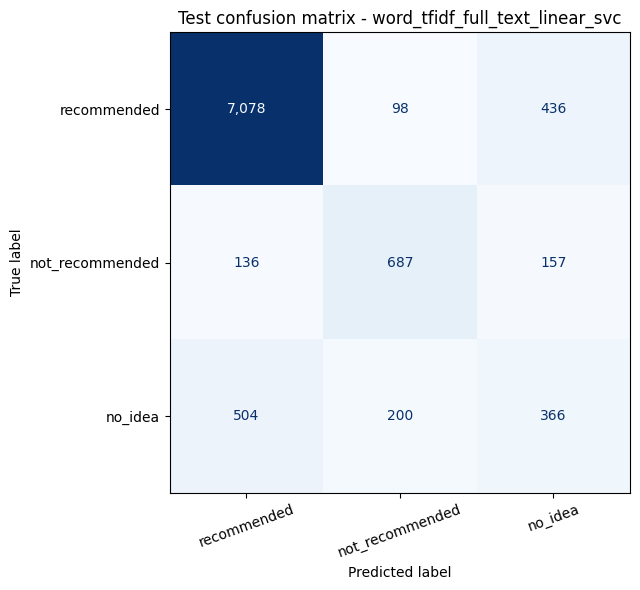

Final test metrics: {
  "macro_f1": 0.6611412090831573,
  "weighted_f1": 0.8383702565246943,
  "accuracy": 0.8415441937487063
}


In [7]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
best_model = best_spec['pipeline_template']
best_text_column = best_spec['text_column']

fit_start = time.perf_counter()
best_model.fit(train_val_df[best_text_column], train_val_df['recommendation_status'])
final_fit_seconds = time.perf_counter() - fit_start

predict_start = time.perf_counter()
test_prediction = best_model.predict(test_df[best_text_column])
test_predict_seconds = time.perf_counter() - predict_start
test_metrics = calculate_metrics(test_df['recommendation_status'], test_prediction)
test_report = classification_report(
    test_df['recommendation_status'],
    test_prediction,
    labels=VALID_LABELS,
    output_dict=True,
    zero_division=0,
)

print_report(f"FINAL TEST - {best_spec['name']}", test_df['recommendation_status'], test_prediction)

cm = confusion_matrix(test_df['recommendation_status'], test_prediction, labels=VALID_LABELS)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=VALID_LABELS).plot(ax=ax, cmap='Blues', values_format=',d', colorbar=False)
ax.set_title(f"Test confusion matrix - {best_spec['name']}")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print('Final test metrics:', json.dumps(test_metrics, indent=2))


In [8]:
model_path = OUTPUT_DIR / 'best_classical_baseline.joblib'
results_path = OUTPUT_DIR / 'baseline_results.csv'
manifest_path = OUTPUT_DIR / 'sampled_split_manifest.csv'
summary_path = OUTPUT_DIR / 'run_summary.json'

joblib.dump(
    {
        'model': best_model,
        'model_name': best_spec['name'],
        'text_column': best_text_column,
        'labels': VALID_LABELS,
        'normalization_version': 'fa_light_v1',
    },
    model_path,
)
all_results = validation_leaderboard.copy()
all_results.insert(0, 'evaluation_split', 'validation')
test_result_row = pd.DataFrame([{
    'evaluation_split': 'test',
    'model': best_spec['name'],
    'text_column': best_text_column,
    'fit_seconds': float(final_fit_seconds),
    'predict_seconds': float(test_predict_seconds),
    **test_metrics,
}])
all_results = pd.concat([all_results, test_result_row], ignore_index=True)
all_results.to_csv(results_path, index=False)

manifest_parts = []
for split_name, frame in split_frames.items():
    part = frame[['id', 'product_id', 'text_group_id', 'recommendation_status']].copy()
    part['split'] = split_name
    manifest_parts.append(part)
pd.concat(manifest_parts, ignore_index=True).to_csv(manifest_path, index=False)

summary = {
    'task': 'digikala_recommendation_status',
    'seed': SEED,
    'huggingface_repo': HF_REPO_ID,
    'huggingface_revision': HF_REVISION,
    'huggingface_filename': HF_FILENAME,
    'huggingface_download_url': HF_DOWNLOAD_URL,
    'source_sha256': HF_EXPECTED_SHA256,
    'source_file': str(comments_path),
    'source_size_bytes': int(comments_path.stat().st_size),
    'sample_fraction': SAMPLE_FRACTION,
    'max_sampled_rows': MAX_SAMPLED_ROWS,
    'data_audit': data_audit,
    'split_profile': split_profile.to_dict(orient='records'),
    'validation_leaderboard': validation_leaderboard.to_dict(orient='records'),
    'selected_model': best_spec['name'],
    'selected_text_column': best_text_column,
    'final_fit_seconds': float(final_fit_seconds),
    'test_predict_seconds': float(test_predict_seconds),
    'test_metrics': test_metrics,
    'test_per_class': {label: test_report[label] for label in VALID_LABELS},
    'versions': {
        'python': sys.version.split()[0],
        'pandas': pd.__version__,
        'scikit_learn': sklearn.__version__,
        'platform': platform.platform(),
    },
}
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

print('Saved artifacts:')
for path in [model_path, results_path, manifest_path, summary_path]:
    print(f' - {path} ({path.stat().st_size / 1_000_000:.2f} MB)')

print('\n' + '#' * 28 + ' COPY THIS SUMMARY ' + '#' * 28)
print(json.dumps(summary, ensure_ascii=False, indent=2))


Saved artifacts:
 - /kaggle/working/best_classical_baseline.joblib (6.89 MB)
 - /kaggle/working/baseline_results.csv (0.00 MB)
 - /kaggle/working/sampled_split_manifest.csv (8.01 MB)
 - /kaggle/working/run_summary.json (0.00 MB)

############################ COPY THIS SUMMARY ############################
{
  "task": "digikala_recommendation_status",
  "seed": 42,
  "huggingface_repo": "RadeAI/Digikala_comments_products",
  "huggingface_revision": "89c3133b169c8d3793db8834f56f32fee33d9db0",
  "huggingface_filename": "digikala-comments.csv",
  "huggingface_download_url": "https://huggingface.co/datasets/RadeAI/Digikala_comments_products/resolve/89c3133b169c8d3793db8834f56f32fee33d9db0/digikala-comments.csv?download=true",
  "source_sha256": "c7a8aa3020334fde8ec24944576a03fe5785e6fe12cd01042f5836632ddf8297",
  "source_file": "/kaggle/working/hf_cache/datasets--RadeAI--Digikala_comments_products/snapshots/89c3133b169c8d3793db8834f56f32fee33d9db0/digikala-comments.csv",
  "source_size_bytes

## Manual test of the saved model

This cell is a sanity check and does not affect model selection.


In [9]:
def prepare_one_text(title='', body='', advantages='', disadvantages=''):
    frame = pd.DataFrame([{
        'title': title,
        'body': body,
        'advantages': advantages,
        'disadvantages': disadvantages,
    }])
    frame = build_model_text(frame)
    return frame.iloc[0][best_text_column]

manual_examples = [
    {'title': 'excellent', 'body': 'excellent quality; I would buy it again'},
    {'title': 'do not buy', 'body': 'the quality was poor and I returned it'},
    {'title': 'average', 'body': 'reasonable for the price, but I expected more'},
]
manual_texts = [prepare_one_text(**example) for example in manual_examples]
manual_predictions = best_model.predict(manual_texts)
display(pd.DataFrame([
    {**example, 'prediction': prediction}
    for example, prediction in zip(manual_examples, manual_predictions)
]))


,title,body,prediction
0,excellent,excellent quality; I would buy it again,recommended
1,do not buy,the quality was poor and I returned it,not_recommended
2,average,"reasonable for the price, but I expected more",no_idea


## Outputs to retain

Retain the following for the next stage:

1. the complete `COPY THIS SUMMARY` block;
2. the complete traceback for any failed cell;
3. the selected Kaggle accelerator and approximate total runtime;
4. the small `baseline_results.csv` file, when available.

These results determine which baseline to retain and support fine-tuning a Transformer encoder on the same split in the next notebook.
